## 교수님을 위한 패치내역
1. 뇌 MRI 로 데이터셋을 변경함.
2. 데이터 증식을 할 때 회전과 밝기, 대비, 채도를 조금 조절함.
3. 증식된 데이터를 출력해서 하나로 합치는 과정 추가. 증식을 대략 10% 정도 추가함 <- 과제
4. 배치 사이즈를 수정
5. 전이학습 모델을 resnet18로 변경하고 feature_extractor 를 true로 설정.
6. torch.nn.Sequential 로 변경
7. 층 몇 단계 더 추가.
8. 활성화 함수를 LeakyReLU로 변경.
9. 최적화 함수를 RMSprop으로 변경.  
10. 이터레이션 변경
11. 에폭 수 축소
12. Early Stopping의 Patience 숫자 변경
13. Early Stopping을 Accuracy를 기준으로 하게 변경.

In [1]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")



using PyTorch version: 2.5.1, Device: cuda


In [3]:
import os
import shutil

if os.path.exists('/content/dataset/'):    # 작업 디렉토리는 dataset

    shutil.rmtree('/content/dataset/')
    print('/content/dataset/ is removed !!!')

##데이터 전처리 과정, train, test, valid로 폴더 분할

In [2]:
# 1. 필요한 라이브러리 설치
#!pip install scikit-learn

# 2. 필요한 라이브러리 임포트
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(source_dir, train_ratio=0.7, valid_ratio=0.15, test_ratio=0.15):
    # 소스 디렉토리 경로 설정
    source_path = Path(source_dir)

    # 현재 경로 확인
    print("현재 작업 디렉토리:", os.getcwd())
    print("소스 디렉토리 경로:", source_path)

    # 클래스 폴더 확인
    classes = [d for d in os.listdir(source_path) if os.path.isdir(source_path / d)]
    print("\n발견된 클래스:", classes)

    # train, valid, test 디렉토리 생성
    base_path = Path(os.getcwd()) / "dataset_split"  # VS Code에서 dataset_split 폴더 생성
    for split in ['train', 'valid', 'test']:
        for class_name in classes:
            os.makedirs(base_path / split / class_name, exist_ok=True)

    # 각 클래스별로 이미지 분할
    for class_name in classes:
        print(f"\n처리 중인 클래스: {class_name}")
        # 현재 클래스의 모든 이미지 파일 수집
        image_files = [f for f in os.listdir(source_path / class_name)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"발견된 이미지 수: {len(image_files)}")

        if not image_files:
            print(f"경고: {class_name} 클래스에서 이미지를 찾을 수 없습니다!")
            continue

        # 데이터 분할
        train_files, temp_files = train_test_split(
            image_files,
            train_size=train_ratio,
            random_state=42
        )

        valid_files, test_files = train_test_split(
            temp_files,
            test_size=test_ratio/(test_ratio + valid_ratio),
            random_state=42
        )

        # 파일 복사
        for file, dest_dir in [(f, 'train') for f in train_files] + \
                            [(f, 'valid') for f in valid_files] + \
                            [(f, 'test') for f in test_files]:
            try:
                shutil.copy2(
                    source_path / class_name / file,
                    base_path / dest_dir / class_name / file
                )
            except Exception as e:
                print(f"파일 복사 중 오류 발생: {file} - {str(e)}")

        print(f"{class_name} 분할 결과:")
        print(f"Train: {len(train_files)} images")
        print(f"Valid: {len(valid_files)} images")
        print(f"Test: {len(test_files)} images")

# 사용 예시
split_dataset('C:/Users/user/Desktop/dataset')  # 바탕화면의 dataset 폴더 경로

현재 작업 디렉토리: c:\Users\user\Desktop\autovehi
소스 디렉토리 경로: C:\Users\user\Desktop\dataset

발견된 클래스: ['blocked', 'free']

처리 중인 클래스: blocked
발견된 이미지 수: 871
blocked 분할 결과:
Train: 609 images
Valid: 131 images
Test: 131 images

처리 중인 클래스: free
발견된 이미지 수: 1871
free 분할 결과:
Train: 1309 images
Valid: 281 images
Test: 281 images


In [3]:
import os

# train data 개수

train_free_list = os.listdir('C:/Users/user/Desktop/dataset_split/train/free')

train_blocked_list = os.listdir('C:/Users/user/Desktop/dataset_split/train/blocked')

print(len(train_free_list), len(train_blocked_list)) #train 초기 데이터 갯수.

# validation data 개수

vali_free_list = os.listdir('C:/Users/user/Desktop/dataset_split/valid/free')

vali_blocked_list = os.listdir('C:/Users/user/Desktop/dataset_split/valid/blocked')

print(len(vali_free_list), len(vali_blocked_list)) #초기 데이터 갯수.

1309 609
281 131


##간단 데이터 증식

In [52]:
# 학습 데이터에 사용할 증식 기법 설정
train_config = transforms.Compose([
    transforms.Resize((300, 300)),  # 이미지를 300x300로 크기 조정
    transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
    transforms.RandomRotation(degrees=12),  # 좌우 회전 (±12도)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # 좌우/상하 이동 (10% 범위)
    transforms.RandomPerspective(distortion_scale=0.2, p=0.6),  # 원근 변환 (왜곡)
    transforms.RandomResizedCrop(size=300, scale=(0.80, 1.2)),  # 확대/축소 (80~120%)
    transforms.ColorJitter(brightness=0.3, contrast=0.1, saturation=0.22, hue=0.1),  # 밝기, 대비, 채도 변화
    transforms.ToTensor()  # 텐서로 변환
])

# 검증 데이터에 사용할 기본 변환 (증식 없이)
validation_config = transforms.Compose([
    transforms.Resize((300, 300)),  # 이미지를 300x300로 크기 조정
    transforms.ToTensor()  # 텐서로 변환
])

# 테스트 데이터에 사용할 기본 변환 (증식 없이)
test_config = transforms.Compose([
    transforms.Resize((300, 300)),  # 이미지를 300x300로 크기 조정
    transforms.ToTensor()  # 텐서로 변환
])

##증식 시작

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset, DataLoader

# 1. 데이터셋 정의 (원본 및 증식)
original_dataset = datasets.ImageFolder('C:/Users/user/Desktop/dataset_split/train', validation_config)
augmented_dataset = datasets.ImageFolder('C:/Users/user/Desktop/dataset_split/train', train_config)

# 2. 목표 데이터 크기 설정
target_size = 5000
current_size = len(original_dataset)

# 3. 증식 데이터셋을 반복적으로 생성하여 목표 크기에 도달
if current_size < target_size:
    # 필요한 증식 횟수 계산
    num_augmentations_needed = (target_size - current_size) // current_size + 1

    # 증식된 데이터셋을 여러 번 복제하여 결합
    augmented_datasets = [augmented_dataset] * num_augmentations_needed
    combined_dataset = ConcatDataset([original_dataset] + augmented_datasets)

    # 목표 크기에 맞게 슬라이싱
    final_dataset = torch.utils.data.Subset(combined_dataset, range(target_size))
else:
    # 이미 목표 크기보다 크거나 같으면 원본 데이터셋만 사용
    final_dataset = original_dataset

# 4. 데이터로더 정의
batch_size = 8
train_loader = DataLoader(final_dataset, batch_size=batch_size, shuffle=True)

# 5. 데이터셋 크기 확인
print(f"Original dataset size: {len(original_dataset)}")
print(f"Augmented dataset size: {len(augmented_dataset)}")
print(f"Final dataset size: {len(final_dataset)}")

NameError: name 'validation_config' is not defined

##데이터 증식 n개 결정방식. 

In [56]:
import os
import random
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from tqdm import tqdm

# 경로 설정
train_dir = "C:/Users/user/Desktop/dataset_split/train"
classes = ["blocked", "free"]  # 이진 분류 클래스

# 각 클래스별 폴더 내의 이미지 파일 경로 수집
image_paths = {cls: [] for cls in classes}
for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    for filename in os.listdir(class_dir):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            image_paths[cls].append(os.path.join(class_dir, filename))

print(f"원본 데이터 개수: blocked={len(image_paths['blocked'])}, free={len(image_paths['free'])}")

# 목표 이미지 개수 설정 (클래스당)
target_per_class = 2500  # 클래스당 2500개, 총 5000개

# 다양한 데이터 증식 변환 정의
augmentations = [
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.RandomRotation(degrees=15),
    transforms.RandomRotation(degrees=30),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=1.0),
    transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.RandomRotation(degrees=10)
    ]),
    transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.1)
    ]),
]

# 저장 디렉토리 생성
augmented_dir = "C:/Users/user/Desktop/dataset_split/augmented_train"
for cls in classes:
    os.makedirs(os.path.join(augmented_dir, cls), exist_ok=True)

# 원본 이미지 복사 (원본 보존)
for cls in classes:
    for i, img_path in enumerate(image_paths[cls]):
        img = Image.open(img_path).convert('RGB')
        img.save(os.path.join(augmented_dir, cls, f"original_{i:04d}.png"))

# 데이터 증식 수행
for cls in classes:
    print(f"클래스 '{cls}' 데이터 증식 중...")
    original_count = len(image_paths[cls])
    needed_count = target_per_class - original_count
    
    if needed_count <= 0:
        print(f"클래스 '{cls}'는 이미 충분한 데이터가 있습니다.")
        continue
    
    augmentations_per_image = needed_count // original_count + 1
    
    count = 0
    pbar = tqdm(total=needed_count)
    
    while count < needed_count:
        # 랜덤하게 원본 이미지 선택
        img_path = random.choice(image_paths[cls])
        img = Image.open(img_path).convert('RGB')
        
        # 랜덤하게 증식 방법 선택
        transform = random.choice(augmentations)
        
        # 이미지 증식
        augmented_img = transform(img)
        
        # 증식된 이미지 저장
        save_path = os.path.join(augmented_dir, cls, f"aug_{count:05d}.png")
        augmented_img.save(save_path)
        
        count += 1
        pbar.update(1)
        
        if count >= needed_count:
            break
    
    pbar.close()

# 결과 확인
augmented_counts = {}
for cls in classes:
    augmented_counts[cls] = len(os.listdir(os.path.join(augmented_dir, cls)))
    print(f"클래스 '{cls}' 증식 후 데이터 개수: {augmented_counts[cls]}")

print(f"총 데이터 개수: {sum(augmented_counts.values())}")

# 데이터 로더 예제 (확인용)
def get_data_loaders(augmented_dir, batch_size=32):
    data_transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = {x: datasets.ImageFolder(os.path.join(augmented_dir, x), data_transform) 
               for x in ['train', 'val']}
    
    dataloaders = {x: torch.utils.data.DataLoader(dataset[x], batch_size=batch_size,
                                                 shuffle=True, num_workers=4)
                  for x in ['train', 'val']}
    
    return dataloaders

원본 데이터 개수: blocked=62, free=74
클래스 'blocked' 데이터 증식 중...


100%|██████████| 2438/2438 [01:03<00:00, 38.43it/s]


클래스 'free' 데이터 증식 중...


100%|██████████| 2426/2426 [00:59<00:00, 41.03it/s]

클래스 'blocked' 증식 후 데이터 개수: 2500
클래스 'free' 증식 후 데이터 개수: 2500
총 데이터 개수: 5000


##데이터셋 정의

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

# 데이터 변환 정의
data_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 원본 데이터셋 로드
original_dir = "C:/Users/user/Desktop/dataset_split/train"
original_dataset = datasets.ImageFolder(root=original_dir, transform=data_transform)

# 증식된 데이터셋 로드
augmented_dir = "C:/Users/user/Desktop/dataset_split/augmented_train"
augmented_dataset = datasets.ImageFolder(root=augmented_dir, transform=data_transform)

# 원본과 증식된 데이터셋 결합
combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

# DataLoader 설정
BATCH_SIZE = 8

train_dataset_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 검증 및 테스트 데이터셋 로드
validation_dir = "C:/Users/user/Desktop/dataset_split/valid"
test_dir = "C:/Users/user/Desktop/dataset_split/test"

validation_dataset = datasets.ImageFolder(root=validation_dir, transform=data_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transform)

validation_dataset_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 시각화를 위한 labels_map 정의
labels_map = {v: k for k, v in augmented_dataset.class_to_idx.items()}

##valid 결정

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6116778].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7030813..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clippi

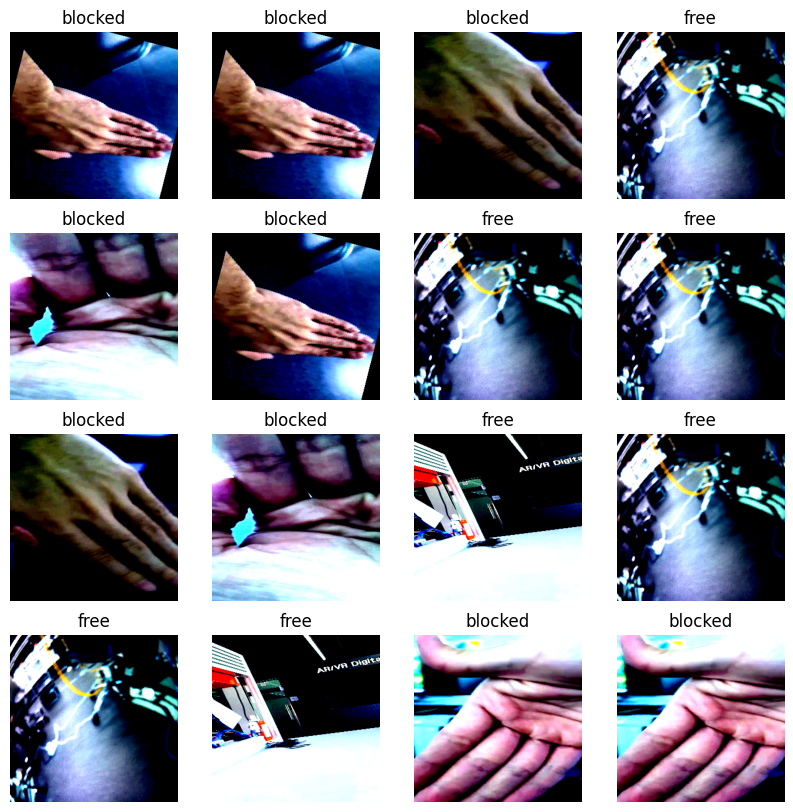

In [5]:
# DataLoader 설정
BATCH_SIZE = 8

train_dataset_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True)

validation_dataset_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 1개의 배치를 추출

images, labels = next(iter(train_dataset_loader))

import matplotlib.pyplot as plt

# ImageFolder의 속성 값인 class_to_idx를 할당

#labels_map = { v:k  for k, v in train_dataset.class_to_idx.items() } #증식 활용하려면 Concat 써야하는데 그것을 활용하면 이 코드는 무력화됨.
labels_map = {v: k for k, v in original_dataset.class_to_idx.items()} #아래 코드로 교체해야한다.

figure = plt.figure(figsize=(10, 10))

cols, rows = 4, 4

# 이미지 출력

for i in range(1, cols*rows+1):

    sample_idx = torch.randint(len(images), size=(1,)).item()
    img, label = images[sample_idx], labels[sample_idx].item()

    figure.add_subplot(rows, cols, i)

    plt.title(labels_map[label])
    plt.axis("off")

    # 본래 이미지의 shape은 (3, 300, 300) 인데,
    # 이를 imshow() 함수로 이미지 시각화 하기 위하여 (300, 300, 3)으로 shape 변경을 한 후 시각화
    plt.imshow(torch.permute(img, (1, 2, 0)))

plt.show()

### Pytorch에서 제공되는 모델과 사전 학습된 가중치
https://pytorch.org/vision/stable/models.html

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

# 사전 학습된 모델 로드 (예: MobileNetV2)
pretrained_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

class MyTransferLearningModel(torch.nn.Module):
    def __init__(self, pretrained_model, feature_extractor, num_classes):
        super().__init__()
        if feature_extractor:
            for param in pretrained_model.parameters():
                param.requires_grad = False  # Fine-tuning 비활성화
        
        # 출력층 재정의 (num_classes에 따라 동적 설정)
        pretrained_model.classifier = torch.nn.Sequential(
            torch.nn.Linear(pretrained_model.classifier[1].in_features, 64),  # MobileNet_V2에서는 [1]이 맞습니다
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(64, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, num_classes)  # num_classes를 동적으로 설정
        )
        self.model = pretrained_model
        
    def forward(self, data):
        logits = self.model(data)
        return logits

# Feature Extractor 여부 설정
feature_extractor = True  # True: Feature Extractor, False: Fine Tuning

# 디바이스 설정 (GPU 사용 가능 여부 확인)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 정의 및 GPU로 이동
num_classes = 2  # blocked, free (2가지 분류)
model = MyTransferLearningModel(pretrained_model, feature_extractor, num_classes=num_classes).to(DEVICE)

# 손실 함수 정의
loss_function = nn.CrossEntropyLoss()

# 옵티마이저 정의 (Feature Extractor 모드 고려)
if feature_extractor:
    optimizer = torch.optim.RMSprop(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
else:
    optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 모델 구조 출력
print(model)

MyTransferLearningModel(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kern

In [7]:
def model_train(dataloader, model, loss_function, optimizer):

    model.train()   # 신경망을 학습모드(모델 파라미터를 업데이트 하는)로 전환

    train_loss_sum = train_correct = train_total = 0

    total_train_batch = len(dataloader)    # 훈련데이터셋을 batch로 나눈 수 = iteration 수

    for images, labels in dataloader:     # images에는 이미지, labels에는 0 또는 1 숫자

        x_train = images.to(DEVICE)       # images.shape = (batch_size, 3, 300, 300)
        y_train = labels.to(DEVICE)

        outputs = model(x_train)          # outputs.shape = (batch_size, 2)
        loss = loss_function(outputs, y_train)

        # 옵티마이저를 이용한 모델 파라미터 최적화
        optimizer.zero_grad()    # 미분값 초기화
        loss.backward()          # 미분 계산
        optimizer.step()         # 파라미터 업데이트

        train_loss_sum += loss.item()    # 1개의 batch에 대한 오차의 합

        train_total += y_train.size(0)   # y_train 텐서 shape의 첫번째 차원의 값(즉, 1개의 batch size 크기를 의미)
        train_correct += ((torch.argmax(outputs, 1)==y_train)).sum().item()       # 1개의 batch에 대해 예측 값과 정답이 일치하는 개수의 합
                                                                                  # '1'은 최대값을 찾을 때 참조할 축(axis)를 의미.
                                                                                  # outputs의 shape이 2차원이라서, 2번째 차원을 참조하라는 의미

    train_avg_loss = train_loss_sum / total_train_batch      # 평균 오차를 계산
    train_avg_accuracy = 100*train_correct / train_total      # 평균 정확도를 계산

    return (train_avg_loss, train_avg_accuracy)


def model_evaluate(dataloader, model, loss_function, optimizer):

    model.eval()       # 신경망을 추론(검증)모드로 전환

    with torch.no_grad():        # 미분하지 않겠다는 것(파라미터를 업데이트 시키지 않겠다는 의미)

        val_loss_sum = val_correct = val_total = 0

        total_val_batch = len(dataloader)      # 검증데이터셋을 batch로 나눈 수 = iteration 수

        for images, labels in dataloader:      # images에는 이미지, labels에는 0 또는 1 숫자

            x_val = images.to(DEVICE)          # images.shape = (batch_size, 3, 300, 300)
            y_val = labels.to(DEVICE)

            outputs = model(x_val)             # outputs.shape = (batch_size, 2)
            loss = loss_function(outputs, y_val)

            val_loss_sum += loss.item()        # 1개의 batch에 대한 오차의 합

            val_total += y_val.size(0)         # y_val 텐서 shape의 첫번째 차원의 값(즉, 1개의 batch size 크기를 의미)
            val_correct += ((torch.argmax(outputs, 1)==y_val)).sum().item()    # 1개의 batch에 대해 예측 값과 정답이 일치하는 개수의 합
                                                                               # '1'은 최대값을 찾을 때 참조할 축(axis)를 의미.
                                                                               # outputs의 shape이 2차원이라서, 2번째 차원을 참조하라는 의미

        val_avg_loss = val_loss_sum / total_val_batch    # 평균 오차를 계산
        val_avg_accuracy = 100*val_correct / val_total   # 평균 정확도를 계산

    return (val_avg_loss, val_avg_accuracy)

def model_test(dataloader, model):

    model.eval()       # 신경망을 추론(검증)모드로 전환

    with torch.no_grad():      # 미분하지 않겠다는 것(파라미터를 업데이트 시키지 않겠다는 의미)

        test_loss_sum = test_correct = test_total = 0

        total_test_batch = len(dataloader)       # 테스트데이터셋을 batch로 나눈 수 = iteration 수

        for images, labels in dataloader:        # images에는 이미지, labels에는 0 또는 1 숫자

            x_test = images.to(DEVICE)           # images.shape = (batch_size, 3, 300, 300)
            y_test = labels.to(DEVICE)

            outputs = model(x_test)              # outputs.shape = (batch_size, 2)
            loss = loss_function(outputs, y_test)

            test_loss_sum += loss.item()         # 1개의 batch에 대한 오차의 합

            test_total += y_test.size(0)         # y_test 텐서 shape의 첫번째 차원의 값(즉, 1개의 batch size 크기를 의미)
            test_correct += ((torch.argmax(outputs, 1)==y_test)).sum().item()  # 1개의 batch에 대해 예측 값과 정답이 일치하는 개수의 합
                                                                               # '1'은 최대값을 찾을 때 참조할 축(axis)를 의미.
                                                                               # outputs의 shape이 2차원이라서, 2번째 차원을 참조하라는 의미

        test_avg_loss = test_loss_sum / total_test_batch     # 평균 오차를 계산
        test_avg_accuracy = 100*test_correct / test_total    # 평균 정확도를 계산

        print('accuracy:', test_avg_accuracy)
        print('loss:', test_avg_loss)

##Early Stopping이 적용된 학습 시작.

In [8]:
from datetime import datetime

train_loss_list = []
train_accuracy_list = []

val_loss_list = []
val_accuracy_list = []

start_time = datetime.now()

EPOCHS = 10
BEST_MODEL_PATH = 'MobileNetV2_best_model3.pth'
#best_val_loss = float('inf')  # 검증 손실 초기값을 무한대로 설정
best_val_acc = 0
patience = 5  # 성능 향상이 없을 경우 조기 종료를 위한 에포크 수
early_stop_counter = 0  # 성능 향상 실패 에포크 카운터

for epoch in range(EPOCHS):
    #==============  model train  ================
    train_avg_loss, train_avg_accuracy = model_train(train_dataset_loader, model, loss_function, optimizer)

    train_loss_list.append(train_avg_loss)
    train_accuracy_list.append(train_avg_accuracy)
    #=============================================

    #============  model evaluation  ==============
    val_avg_loss, val_avg_accuracy = model_evaluate(validation_dataset_loader, model, loss_function, optimizer)

    val_loss_list.append(val_avg_loss)
    val_accuracy_list.append(val_avg_accuracy)
    #=============================================

    print('epoch:', '%02d' % (epoch + 1),
          'train loss =', '{:.3f}'.format(train_avg_loss), 'train acc =', '{:.3f}'.format(train_avg_accuracy),
          'val loss =', '{:.3f}'.format(val_avg_loss), 'val acc =', '{:.3f}'.format(val_avg_accuracy))

    # Early Stopping Logic
#    if val_avg_loss < best_val_loss:
#        best_val_loss = val_avg_loss
    if val_avg_accuracy > best_val_acc:  # loss와 반대로 크면 좋음..
        best_val_acc = val_avg_accuracy  # 맞춰준다.
        early_stop_counter = 0
        # Save the best model
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        early_stop_counter += 1

    # Check if early stopping condition is met
    if early_stop_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

end_time = datetime.now()

print('elapsed time => ', end_time - start_time)

epoch: 01 train loss = 0.145 train acc = 94.666 val loss = 0.017 val acc = 99.272
epoch: 02 train loss = 0.096 train acc = 96.542 val loss = 0.006 val acc = 99.757
epoch: 03 train loss = 0.086 train acc = 96.854 val loss = 0.004 val acc = 100.000
epoch: 04 train loss = 0.079 train acc = 97.187 val loss = 0.003 val acc = 100.000
epoch: 05 train loss = 0.066 train acc = 97.651 val loss = 0.001 val acc = 100.000
epoch: 06 train loss = 0.065 train acc = 97.631 val loss = 0.007 val acc = 100.000
epoch: 07 train loss = 0.068 train acc = 97.913 val loss = 0.002 val acc = 100.000
epoch: 08 train loss = 0.055 train acc = 98.104 val loss = 0.002 val acc = 99.757
Early stopping at epoch 8
elapsed time =>  0:04:36.105185


accuracy: 100.0
loss: 0.0032047967570553427


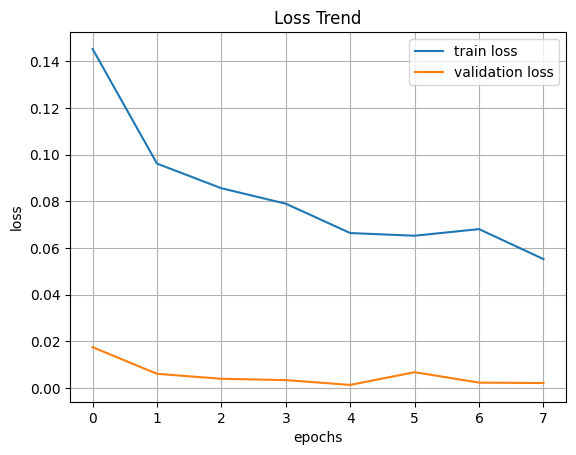

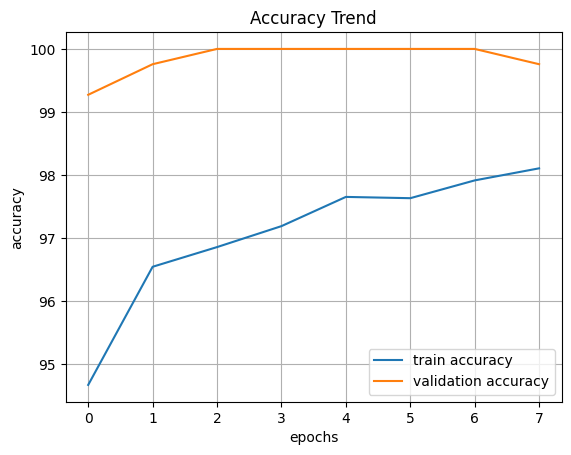

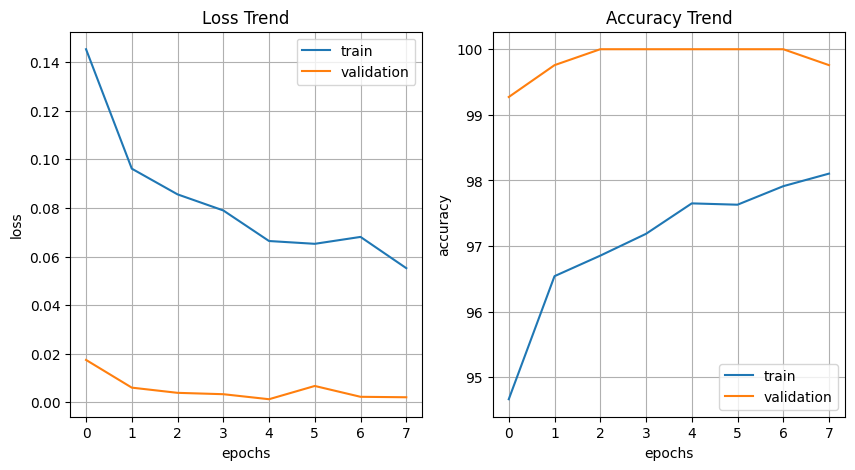

In [9]:
# test dataset 으로 정확도 및 오차 테스트

model_test(test_dataset_loader, model)


import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()

plt.plot(train_loss_list, label='train loss')
plt.plot(val_loss_list, label='validation loss')

plt.legend()

plt.show()


import matplotlib.pyplot as plt

plt.title('Accuracy Trend')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()

plt.plot(train_accuracy_list, label='train accuracy')
plt.plot(val_accuracy_list, label='validation accuracy')

plt.legend()

plt.show()


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(train_loss_list, label='train')
plt.plot(val_loss_list, label='validation')
plt.legend()

plt.subplot(1,2,2)
plt.title('Accuracy Trend')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()
plt.plot(train_accuracy_list, label='train')
plt.plot(val_accuracy_list, label='validation')
plt.legend()

plt.show()



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to th

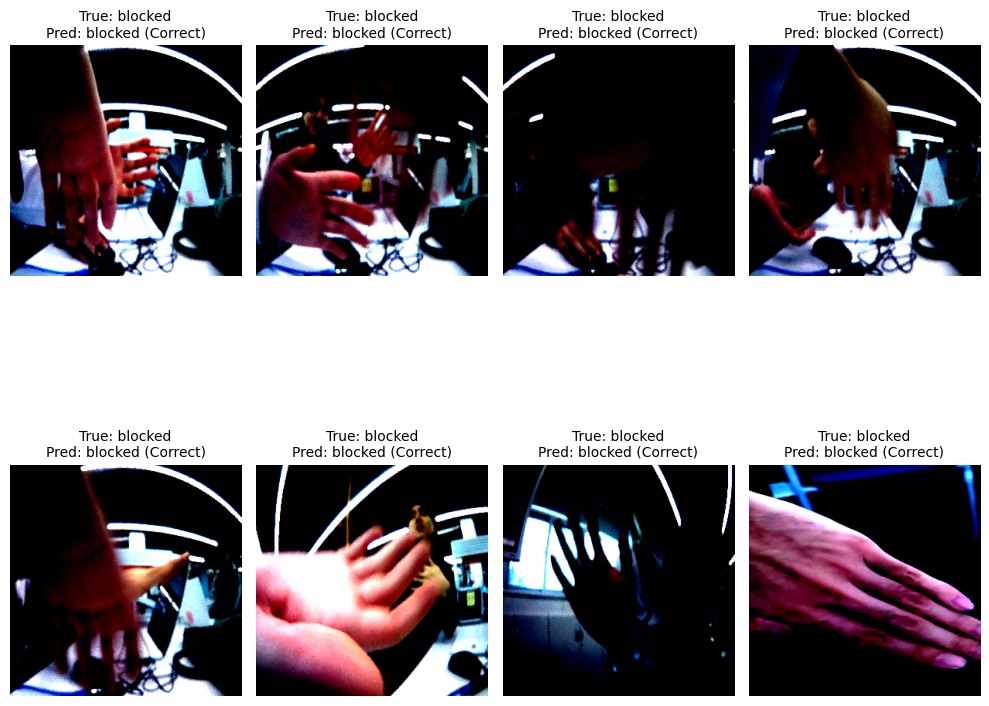

In [10]:
# 8개의 이미지를 출력하여 모델 예측 결과를 시각화
#figure = plt.figure(figsize=(12, 12))
figure = plt.figure(figsize=(10, 10))

cols, rows = 4, 2
images, labels = next(iter(test_dataset_loader))  # 테스트 데이터셋에서 1개의 배치 읽어오기

images = images.to(DEVICE)
labels = labels.to(DEVICE)

# 모델 추론
outputs = model(images)
predicted_labels = torch.argmax(outputs, 1)

# ImageFolder의 class_to_idx를 이용하여 label map 생성
labels_map = {v: k for k, v in test_dataset.class_to_idx.items()}

# 16개의 이미지 시각화
for i in range(1, cols * rows + 1):
    sample_idx = i - 1  # 배치 내에서의 인덱스
    img = images[sample_idx].cpu()
    label = labels[sample_idx].item()
    predicted_label = predicted_labels[sample_idx].item()

    # 정답 여부 확인
    is_correct = "Correct" if label == predicted_label else "Wrong"
    title = f"True: {labels_map[label]}\nPred: {labels_map[predicted_label]} ({is_correct})"

    # 1개의 subplot 추가
    figure.add_subplot(rows, cols, i)
    plt.title(title, fontsize=10)  # 폰트 크기 지정
    plt.axis("off")

    # 이미지의 shape 변경 (3, 300, 300) -> (300, 300, 3)
    plt.imshow(torch.permute(img, (1, 2, 0)))

plt.tight_layout()
plt.show()

##full model save

In [39]:
import os
import torch

# 현재 사용자의 바탕화면 경로 설정
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# 저장할 파일 경로
save_path = os.path.join(desktop_path, "full_model.pth")

# 모델 전체 저장
torch.save(model, save_path)

print(f"모델이 성공적으로 저장되었습니다: {save_path}")

모델이 성공적으로 저장되었습니다: C:\Users\user\Desktop\full_model.pth
